In [20]:
import numpy as np
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

from prophet import Prophet
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric, plot_yearly

In [21]:
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"

In [22]:
df[3011373971] = df[3011373971].replace(0, np.nan)

In [23]:
df[3011373971]=df[3011373971].interpolate(method ='linear', limit_direction ='forward')

In [24]:
df = pd.concat([df, df])
with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.precision",
    3,
):
    print(df)

           3003858507 3001084033  3011373971 3001449459 3011504476
idx                                                               
2019-06-01     1246.0     7160.0       440.0      960.0     1560.0
2019-07-01     1081.0     6520.0       600.0      920.0     1280.0
2019-08-01     1184.0     6840.0       680.0     1120.0     1360.0
2019-09-01     1549.0     7440.0       760.0     1040.0     1680.0
2019-10-01     2045.0     6920.0       560.0     1120.0     1680.0
2019-11-01     4017.0     6920.0       520.0     1240.0     2920.0
2019-12-01     2386.0     7240.0       320.0     1000.0     1960.0
2020-01-01     4239.0     6560.0       440.0     1120.0     2280.0
2020-02-01     2854.0     7440.0       280.0     1200.0     2480.0
2020-03-01     3208.0     7440.0       320.0     1360.0     2240.0
2020-04-01     1048.0     5640.0       440.0     1080.0     1480.0
2020-05-01     1313.0     4880.0       416.0     1040.0     1280.0
2020-06-01     1174.0     5080.0       392.0     1320.0     12

In [25]:
new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")

df.index = new_index

In [26]:
#auto_arima(
#    df[3011373971],
#    m=12,
#    seasonal=True,
#).summary()

In [27]:
train = df.iloc[:80]
test = df.iloc[80:]

test = test.astype(float)
train = train.astype(float)

model = SARIMAX(train[3011373971], order=(3, 0, 0), seasonal_order=(1,2,1,12))
results = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.71044D+00    |proj g|=  3.47161D-02


 This problem is unconstrained.



At iterate    5    f=  4.69502D+00    |proj g|=  4.14158D-02

At iterate   10    f=  4.69120D+00    |proj g|=  5.74244D-03

At iterate   15    f=  4.69062D+00    |proj g|=  4.58819D-03

At iterate   20    f=  4.67837D+00    |proj g|=  7.31606D-02

At iterate   25    f=  4.59906D+00    |proj g|=  6.82839D-03

At iterate   30    f=  4.59708D+00    |proj g|=  5.36387D-03

At iterate   35    f=  4.59620D+00    |proj g|=  1.65837D-03

At iterate   40    f=  4.59591D+00    |proj g|=  2.34560D-03

At iterate   45    f=  4.59582D+00    |proj g|=  3.77946D-04

At iterate   50    f=  4.59581D+00    |proj g|=  1.99393D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

In [28]:
start = len(train)
end = len(train) + len(test) - 1
interpolated_predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

intepolated_future_predictions = results.predict(
    start=end, end=end + 48, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

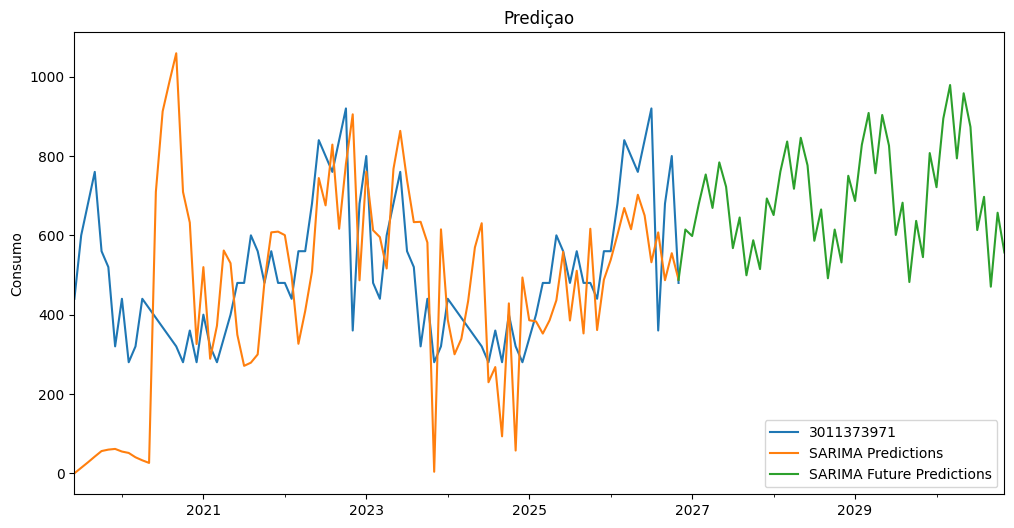

In [29]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3011373971].plot(legend=True, figsize=(12, 6), title=title)
interpolated_predictions.plot(legend=True)
intepolated_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [30]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"

df = pd.concat([df, df])

new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")

df.index = new_index

In [31]:
df.reset_index(inplace=True)
df = df.rename(columns={"index": "DS"})

df.columns = ["ds", "y1", "y2", "y3", "y4", "y5"]

df["y1"] = df["y1"].astype(int)
df["y2"] = df["y2"].astype(int)
df["y3"] = df["y3"].astype(int)
df["y4"] = df["y4"].astype(int)
df["y5"] = df["y5"].astype(int)

df.columns = ["ds", "y1", "y2", "y", "y4", "y5"]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      90 non-null     datetime64[ns]
 1   y1      90 non-null     int64         
 2   y2      90 non-null     int64         
 3   y       90 non-null     int64         
 4   y4      90 non-null     int64         
 5   y5      90 non-null     int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 4.3 KB


In [32]:
train = df.iloc[:80]
test = df.iloc[79:]

m = Prophet(growth='flat', seasonality_mode='additive',yearly_seasonality=150)


m.fit(train)
future = m.make_future_dataframe(periods=12,freq='MS')
forecast = m.predict(future)

11:02:26 - cmdstanpy - INFO - Chain [1] start processing
11:02:28 - cmdstanpy - INFO - Chain [1] done processing


<Axes: xlabel='ds'>

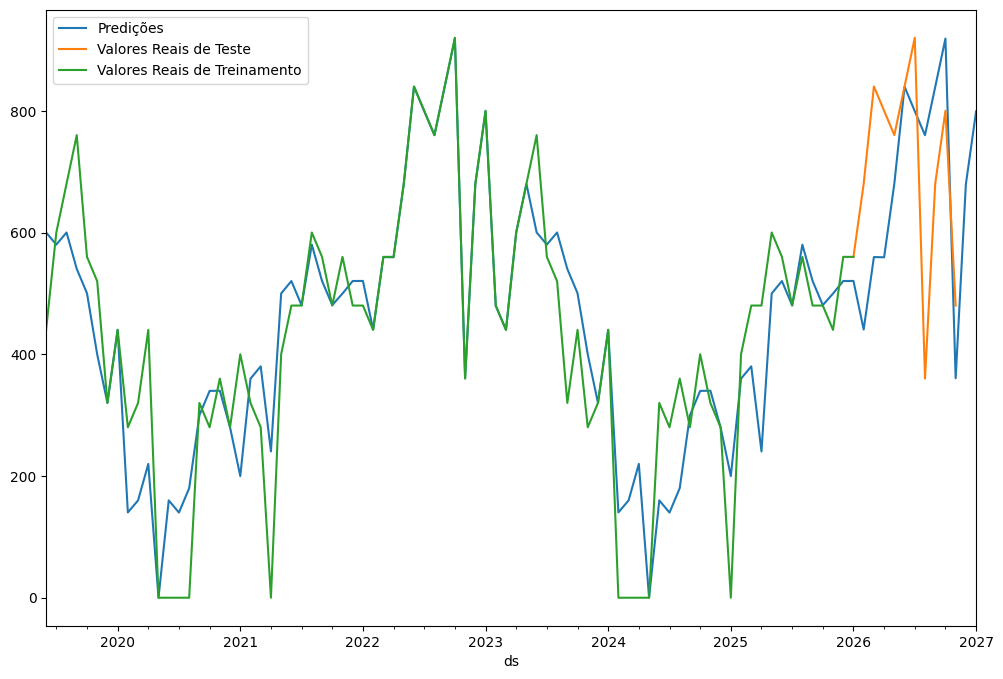

In [33]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
test.plot(x='ds',y='y',label='Valores Reais de Teste',legend=True,ax=ax)
train.plot(x='ds',y='y',label='Valores Reais de Treinamento',legend=True,ax=ax)

In [34]:
df_cv = cross_validation(m,initial="36 days",period="36 days",horizon="12 days")

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/39 [00:00<?, ?it/s]11:02:28 - cmdstanpy - INFO - Chain [1] start processing
11:02:38 - cmdstanpy - INFO - Chain [1] done processing
  3%|▎         | 1/39 [00:09<06:08,  9.69s/it]11:02:38 - cmdstanpy - INFO - Chain [1] start processing
11:02:46 - cmdstanpy - INFO - Chain [1] done processing
  5%|▌         | 2/39 [00:18<05:28,  8.88s/it]11:02:46 - cmdstanpy - INFO - Chain [1] start processing
11:02:50 - cmdstanpy - INFO - Chain [1] done processing
  8%|▊         | 3/39 [00:21<03:48,  6.36s/it]11:02:50 - cmdstanpy - INFO - Chain [1] start processing
11:02:53 - cmdstanpy - INFO - Chain [1] done processing
 10%|█         | 4/39 [00:24<02:55,  5.00s/it]11:02:53 - cmdstanpy - INFO - Chain [1] start processing
11:02:56 - cmdstanpy - INFO - Chain [1] done processing
 13%|█▎        | 5/39 [00:28<02:37,  4.62s/it]11:02:57 - cmdstanpy - INFO - Chain [1] start processing
11:03:

In [35]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mdape,smape,coverage
0,12 days,1.972305e+08,14043.878839,6424.830004,3.592598,1.181722,0.230769


In [36]:
m = Prophet(growth='flat', seasonality_mode='additive',yearly_seasonality=150)

m.fit(df)

future = m.make_future_dataframe(periods=48,freq='MS')

forecast = m.predict(future)

forecast.head()

11:11:25 - cmdstanpy - INFO - Chain [1] start processing


11:11:27 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-06-01,-17.293516,456.138792,741.961169,-17.293516,-17.293516,617.402934,617.402934,617.402934,617.402934,617.402934,617.402934,0.0,0.0,0.0,600.109418
1,2019-07-01,-17.293516,444.620346,717.609439,-17.293516,-17.293516,597.465973,597.465973,597.465973,597.465973,597.465973,597.465973,0.0,0.0,0.0,580.172457
2,2019-08-01,-17.293516,467.515854,744.212032,-17.293516,-17.293516,617.157986,617.157986,617.157986,617.157986,617.157986,617.157986,0.0,0.0,0.0,599.864470
3,2019-09-01,-17.293516,409.700608,679.464683,-17.293516,-17.293516,557.396689,557.396689,557.396689,557.396689,557.396689,557.396689,0.0,0.0,0.0,540.103173
4,2019-10-01,-17.293516,352.730314,634.515223,-17.293516,-17.293516,517.546289,517.546289,517.546289,517.546289,517.546289,517.546289,0.0,0.0,0.0,500.252773


<Axes: xlabel='ds'>

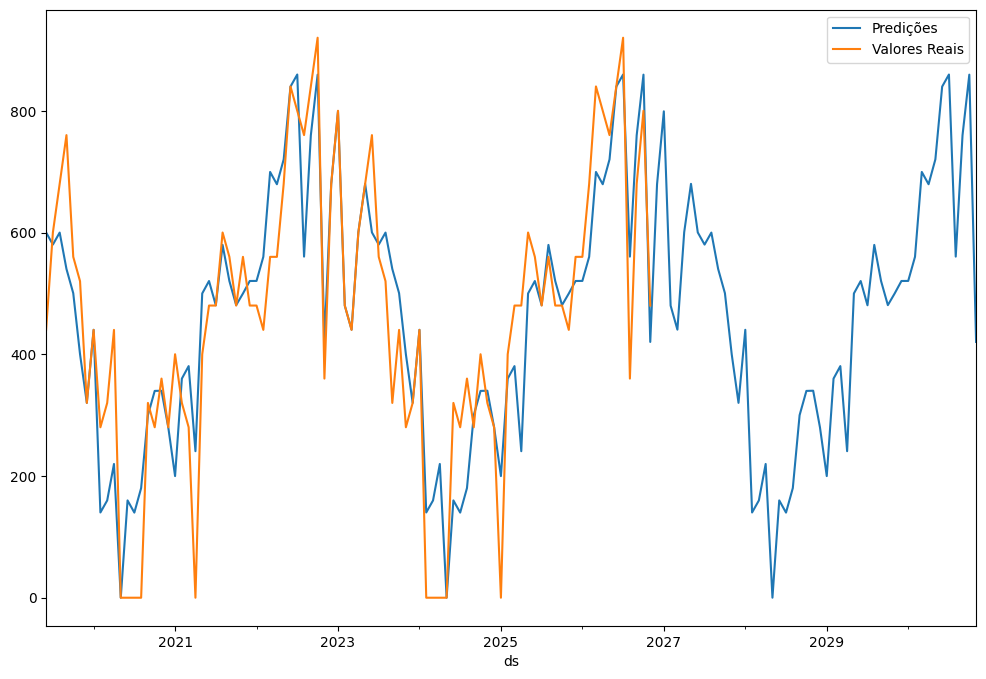

In [37]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
df.plot(x='ds',y='y',label='Valores Reais',legend=True,ax=ax)